In [6]:
import os, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create output folder for saved charts
CHART_DIR = "/Users/delilahhollander/Downloads/dsa400_SouthSide/poverty demographics/charts"
os.makedirs(CHART_DIR, exist_ok=True)


In [7]:
DATA_DIR = "/Users/delilahhollander/Downloads/dsa400_SouthSide/poverty demographics"

def parse_number(val):
    if not isinstance(val, str): return None
    val = val.strip().replace(",", "").replace("%", "").replace("±", "")
    if val in ("", "-", "**", "(X)", "N"): return None
    try: return float(val)
    except ValueError: return None

def find_row(df, keyword):
    label_col = df.columns[0]
    mask = df[label_col].str.strip().str.lower().str.contains(keyword.lower(), na=False)
    matches = df[mask]
    return matches.iloc[0] if len(matches) > 0 else None

def get_val(row, idx):
    if row is None: return None
    return parse_number(str(row.iloc[idx]))

files = sorted([f for f in os.listdir(DATA_DIR) if f.startswith("ACSST5Y") and f.endswith(".csv")])
years = []
acs = {}
for f in files:
    match = re.search(r"ACSST5Y(\d{4})", f)
    if match:
        y = int(match.group(1))
        years.append(y)
        acs[y] = pd.read_csv(os.path.join(DATA_DIR, f))
years.sort()

rows = []
for y in years:
    df = acs[y]
    pop_row = find_row(df, "population for whom poverty status is determined")
    rows.append({
        "year": y,
        "population": get_val(pop_row, 1),
        "poverty_pct": get_val(pop_row, 5),
        "under_18": get_val(find_row(df, "under 18 years"), 1),
        "age_18_64": get_val(find_row(df, "18 to 64 years"), 1),
        "age_65_plus": get_val(find_row(df, "65 years and over"), 1),
        "male": get_val(find_row(df, "male"), 1),
        "female": get_val(find_row(df, "female"), 1),
        "edu_pop_25_plus": get_val(find_row(df, "population 25 years and over"), 1),
        "less_than_hs": get_val(find_row(df, "less than high school"), 1),
        "hs_graduate": get_val(find_row(df, "high school graduate"), 1),
        "some_college": get_val(find_row(df, "some college"), 1),
        "bachelors_plus": get_val(find_row(df, "bachelor's degree or higher"), 1),
    })

demo = pd.DataFrame(rows)
print("Data loaded:")
demo


Data loaded:


,year,population,poverty_pct,under_18,age_18_64,age_65_plus,male,female,edu_pop_25_plus,less_than_hs,hs_graduate,some_college,bachelors_plus
0,2014,9891.0,24.2,643.0,8276.0,972.0,5349.0,4542.0,6198.0,322.0,322.0,1174.0,2952.0
1,2015,9461.0,23.6,513.0,7812.0,1136.0,5114.0,4347.0,6158.0,313.0,313.0,1124.0,3034.0
2,2016,9895.0,22.8,542.0,8139.0,1214.0,5560.0,4335.0,6661.0,362.0,362.0,1208.0,3493.0
3,2017,10000.0,22.6,537.0,8244.0,1219.0,5530.0,4470.0,6631.0,328.0,328.0,1123.0,3672.0
4,2018,9643.0,20.9,509.0,7852.0,1282.0,5170.0,4473.0,6685.0,322.0,322.0,1030.0,3706.0
5,2019,10036.0,22.3,576.0,8287.0,1173.0,5451.0,4585.0,7078.0,325.0,325.0,1102.0,4062.0
6,2020,10639.0,25.2,542.0,9015.0,1082.0,5704.0,4935.0,7172.0,445.0,445.0,1097.0,4229.0
7,2021,10115.0,24.0,592.0,8548.0,975.0,5055.0,5060.0,7018.0,376.0,376.0,1032.0,4298.0
8,2022,10302.0,21.8,571.0,8773.0,958.0,5249.0,5053.0,7203.0,307.0,307.0,1077.0,4558.0
9,2023,10713.0,18.5,537.0,9003.0,1173.0,5390.0,5323.0,7562.0,361.0,361.0,1439.0,4588.0


Saved as 'total_population.png'


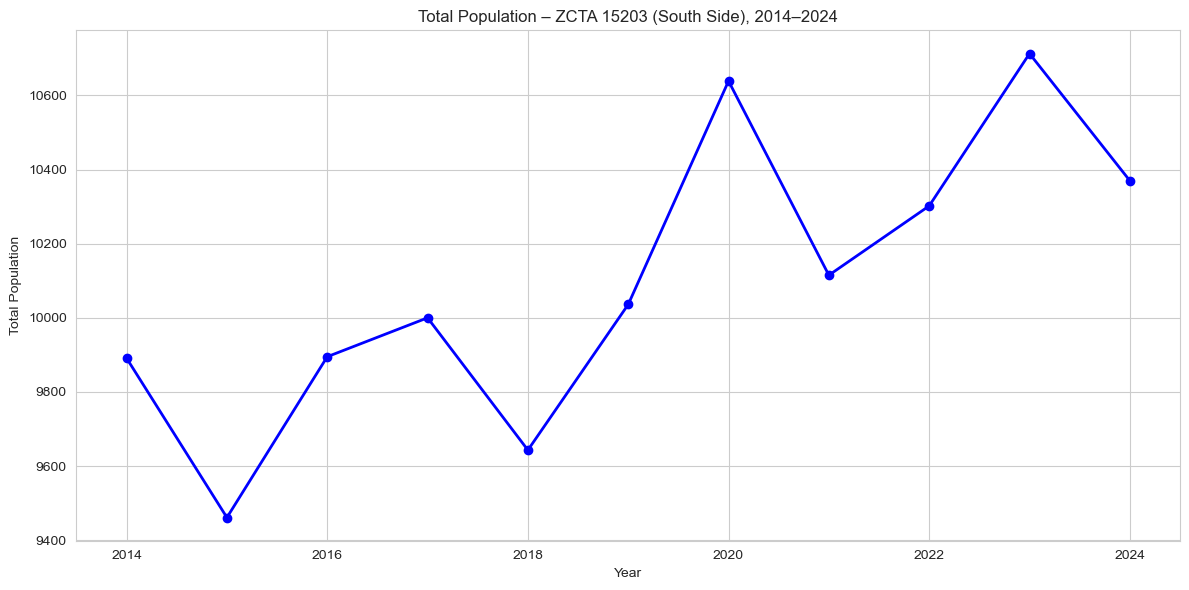

In [8]:
plt.figure()
plt.plot(demo['year'], demo['population'], linewidth=2, color='blue', marker='o', markersize=6)
plt.xlabel('Year')
plt.ylabel('Total Population')
plt.title('Total Population – ZCTA 15203 (South Side), 2014–2024')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'total_population.png'), dpi=300, bbox_inches='tight')
print("Saved as 'total_population.png'")
plt.show()

Saved as 'age_breakdown_stacked.png'


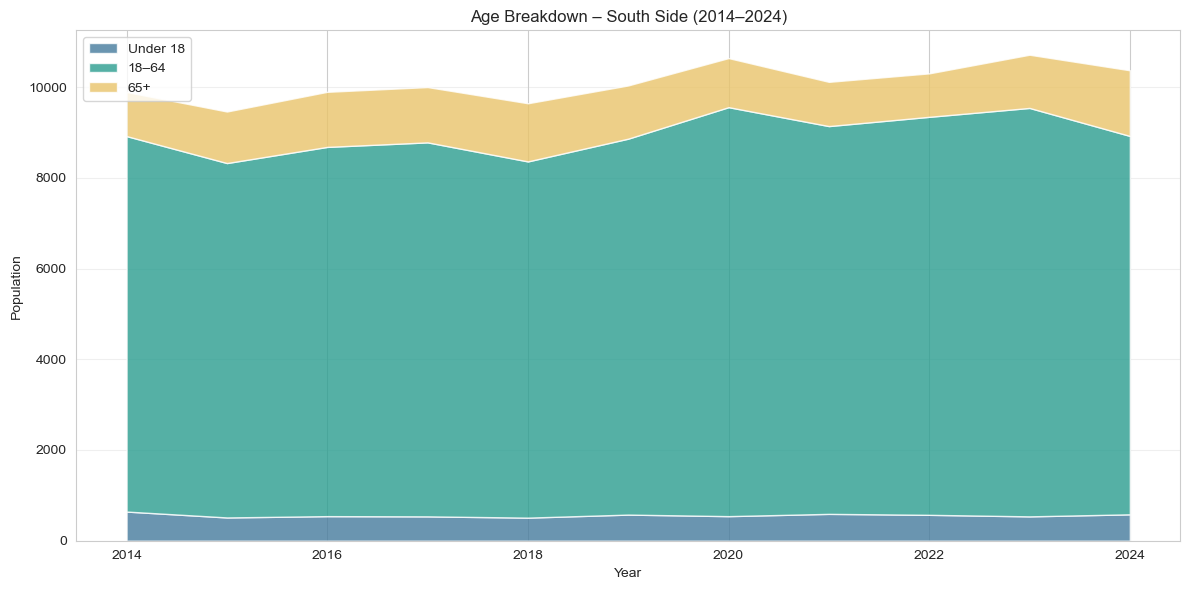

In [9]:
plt.figure()
plt.stackplot(demo['year'],
              demo['under_18'], demo['age_18_64'], demo['age_65_plus'],
              labels=['Under 18', '18–64', '65+'],
              colors=['#457b9d', '#2a9d8f', '#e9c46a'], alpha=0.8)
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Age Breakdown – South Side (2014–2024)')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'age_breakdown_stacked.png'), dpi=300, bbox_inches='tight')
print("Saved as 'age_breakdown_stacked.png'")
plt.show()

Saved as 'age_pct_lines.png'


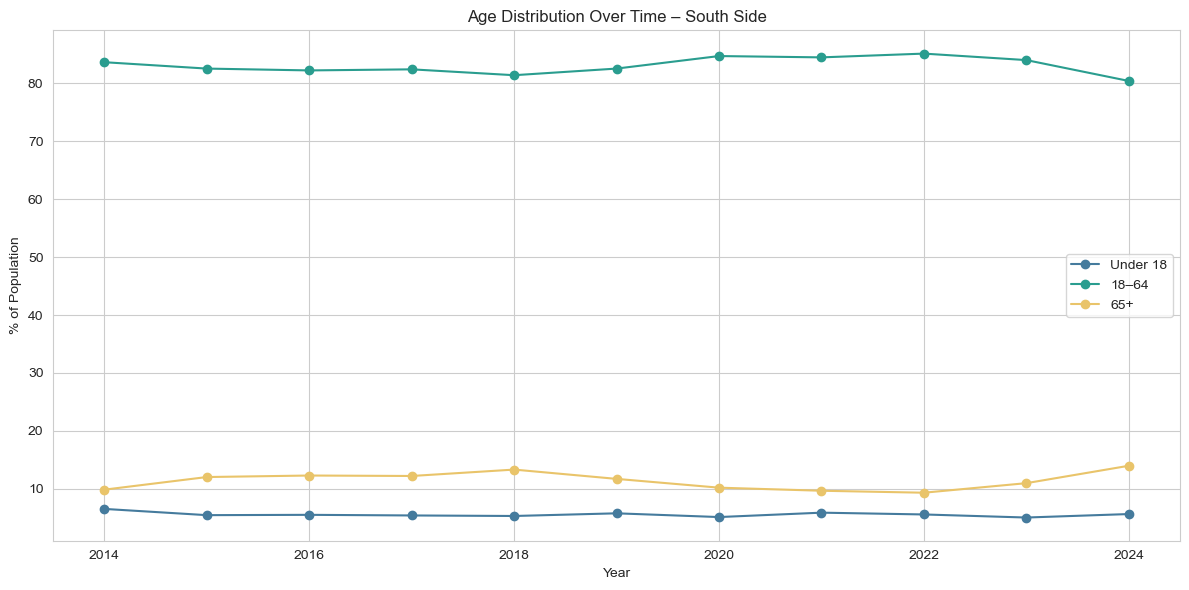

In [10]:
demo['pct_under_18'] = demo['under_18'] / demo['population'] * 100
demo['pct_18_64'] = demo['age_18_64'] / demo['population'] * 100
demo['pct_65_plus'] = demo['age_65_plus'] / demo['population'] * 100

plt.figure()
plt.plot(demo['year'], demo['pct_under_18'], 'o-', label='Under 18', color='#457b9d')
plt.plot(demo['year'], demo['pct_18_64'], 'o-', label='18–64', color='#2a9d8f')
plt.plot(demo['year'], demo['pct_65_plus'], 'o-', label='65+', color='#e9c46a')
plt.xlabel('Year')
plt.ylabel('% of Population')
plt.title('Age Distribution Over Time – South Side')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'age_pct_lines.png'), dpi=300, bbox_inches='tight')
print("Saved as 'age_pct_lines.png'")
plt.show()


Saved as 'sex_breakdown.png'


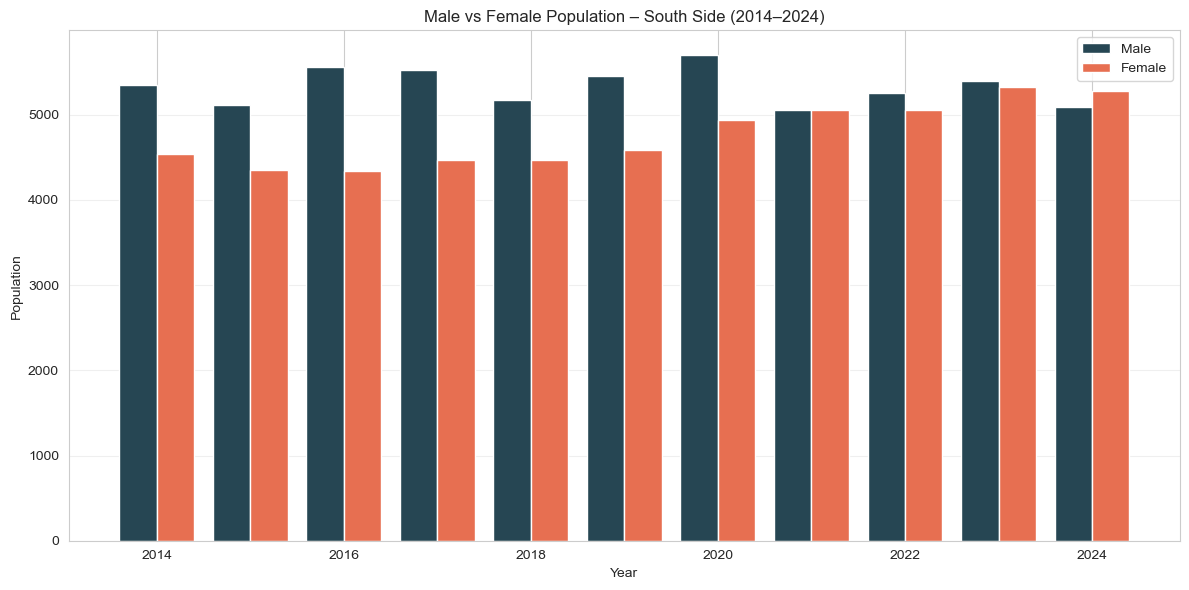

In [11]:
plt.figure()
plt.bar(demo['year'] - 0.2, demo['male'], width=0.4, label='Male', color='#264653')
plt.bar(demo['year'] + 0.2, demo['female'], width=0.4, label='Female', color='#e76f51')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Male vs Female Population – South Side (2014–2024)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'sex_breakdown.png'), dpi=300, bbox_inches='tight')
print("Saved as 'sex_breakdown.png'")
plt.show()


Saved as 'education_stacked_bar.png'


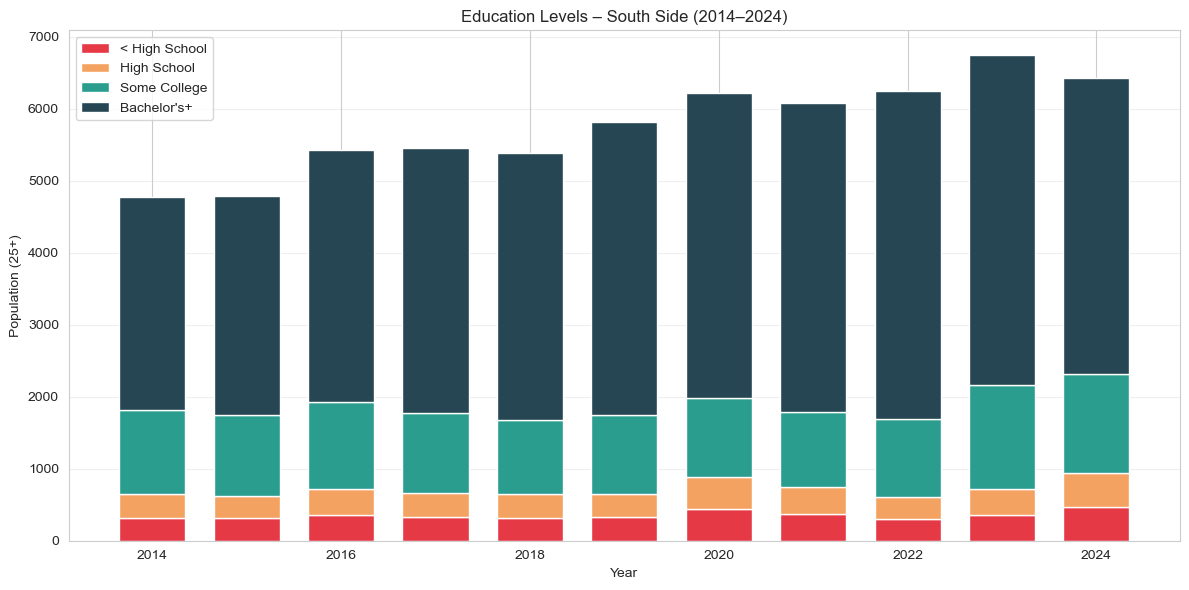

In [12]:
fig, ax = plt.subplots()
bottom = np.zeros(len(demo))
colors = ['#e63946', '#f4a261', '#2a9d8f', '#264653']
labels = ['< High School', 'High School', 'Some College', "Bachelor's+"]
columns = ['less_than_hs', 'hs_graduate', 'some_college', 'bachelors_plus']

for col, label, color in zip(columns, labels, colors):
    vals = demo[col].fillna(0).values
    ax.bar(demo['year'], vals, bottom=bottom, label=label, color=color, width=0.7)
    bottom += vals

ax.set_xlabel('Year')
ax.set_ylabel('Population (25+)')
ax.set_title('Education Levels – South Side (2014–2024)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'education_stacked_bar.png'), dpi=300, bbox_inches='tight')
print("Saved as 'education_stacked_bar.png'")
plt.show()


Saved as 'education_pct_lines.png'


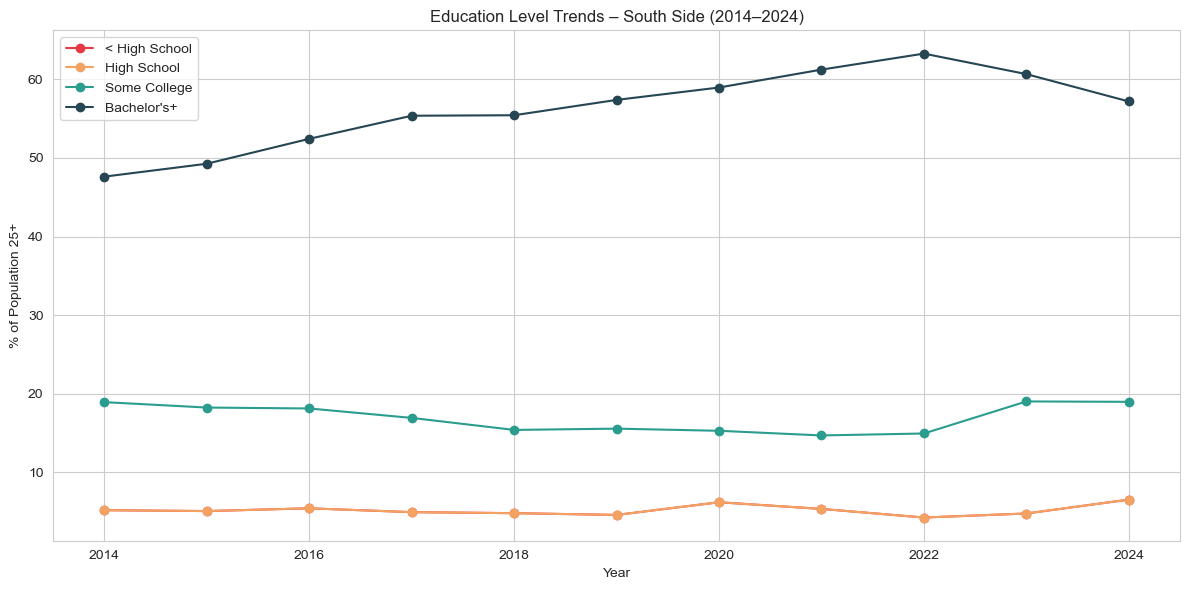

In [13]:
for col in columns:
    demo[f'pct_{col}'] = demo[col] / demo['edu_pop_25_plus'] * 100

plt.figure()
for col, label, color in zip(columns, labels, colors):
    plt.plot(demo['year'], demo[f'pct_{col}'], 'o-', label=label, color=color, linewidth=1.5)

plt.xlabel('Year')
plt.ylabel('% of Population 25+')
plt.title('Education Level Trends – South Side (2014–2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'education_pct_lines.png'), dpi=300, bbox_inches='tight')
print("Saved as 'education_pct_lines.png'")
plt.show()


Saved as 'poverty_rate.png'


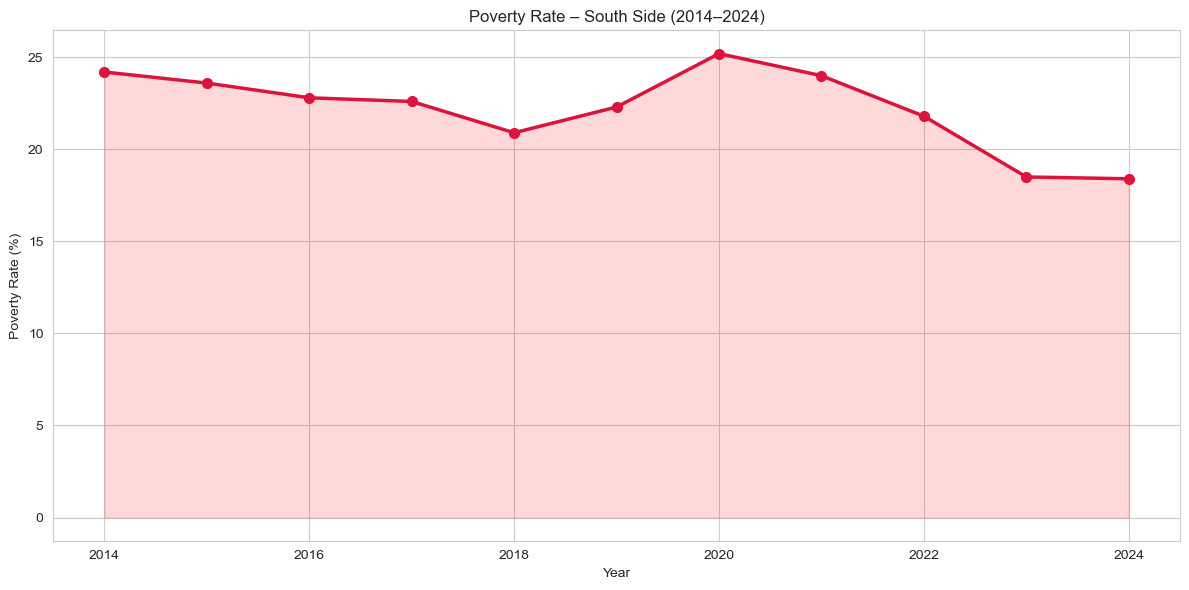

In [14]:
plt.figure()
plt.plot(demo['year'], demo['poverty_pct'], linewidth=2.5, color='crimson', marker='o', markersize=7)
plt.fill_between(demo['year'], demo['poverty_pct'], alpha=0.15, color='red')
plt.xlabel('Year')
plt.ylabel('Poverty Rate (%)')
plt.title('Poverty Rate – South Side (2014–2024)')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'poverty_rate.png'), dpi=300, bbox_inches='tight')
print("Saved as 'poverty_rate.png'")
plt.show()


Saved as 'demographic_comparison.png'


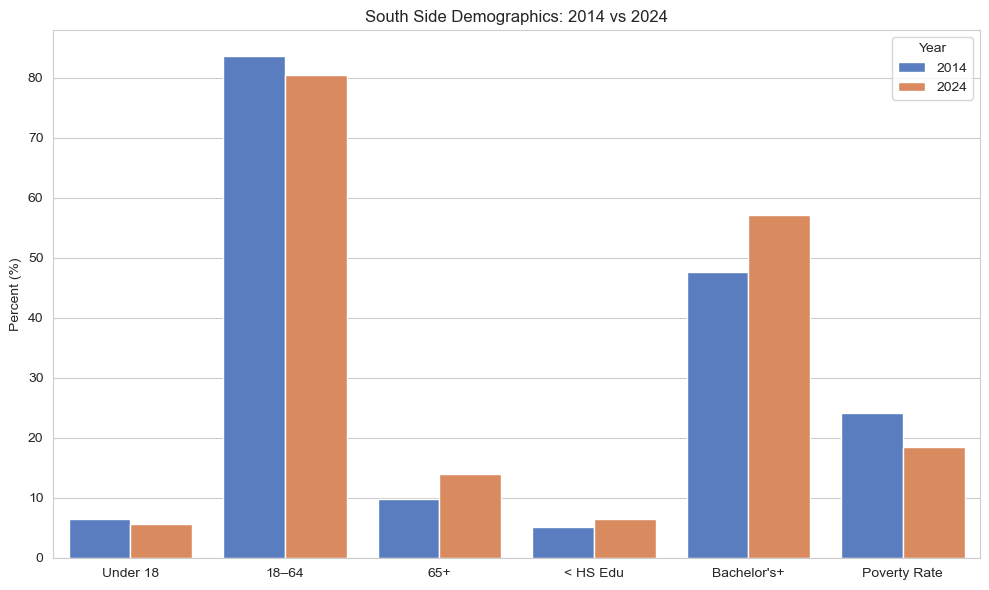

In [15]:
first_yr, last_yr = years[0], years[-1]
compare = demo[demo['year'].isin([first_yr, last_yr])][
    ['year', 'pct_under_18', 'pct_18_64', 'pct_65_plus',
     'pct_less_than_hs', 'pct_bachelors_plus', 'poverty_pct']
].melt(id_vars='year', var_name='metric', value_name='pct')

label_map = {
    'pct_under_18': 'Under 18', 'pct_18_64': '18–64', 'pct_65_plus': '65+',
    'pct_less_than_hs': '< HS Edu', 'pct_bachelors_plus': "Bachelor's+",
    'poverty_pct': 'Poverty Rate'
}
compare['metric'] = compare['metric'].map(label_map)

plt.figure(figsize=(10, 6))
sns.barplot(data=compare, x='metric', y='pct', hue='year', palette='muted')
plt.xlabel('')
plt.ylabel('Percent (%)')
plt.title(f'South Side Demographics: {first_yr} vs {last_yr}')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, 'demographic_comparison.png'), dpi=300, bbox_inches='tight')
print("Saved as 'demographic_comparison.png'")
plt.show()
